# Modellierung mit Prophet — PM2.5 Beijing

**Capstone-Projekt · CRISP-DM Phase 4 (Modeling)**
Bettina Gertjerenken · Kai Steffen

Wir bestimmen zuerst eine **Seasonal-Naive-Baseline** als Messlatte und trainieren dann **Facebook Prophet** in einer aufsteigenden Konfigurations-Leiter — jede Stufe fügt genau **einen** Baustein hinzu, so sieht man dessen Beitrag direkt. Der **Feiertagskalender (CN)** kommt bewusst früh dazu: Kapitel 01 hat gezeigt, dass das Feuerwerk zum chinesischen Neujahr PM2.5 kurzzeitig verzehnfacht.

0. **Seasonal Naive (Baseline)** — muss von jedem echten Modell geschlagen werden,
1. **Basis, univariat** (nur `ds`+`y`) — Referenz,
2. **Basis + Feiertage** (`add_country_holidays("CN")`),
3. **Basis + Feiertage + Wetter-Regressoren**,
4. **Behandelt + Feiertage + Wetter-Regressoren**,
5. **Behandelt + Feiertage + Wetter-Regressoren + Log-Ziel** (gegen die Rechtsschiefe).

Alle Läufe vergleichen wir einheitlich über **MAE**, **RMSE**, **MASE** und **MAPE** — jeweils für das **gesamte Testjahr** und die kurzfristigen Horizonte **8 / 24 / 48 / 72 Stunden**. Danach erweitern wir das Ganze auf **alle 12 Stationen** und zeigen den **Datenverlauf** (echt vs. Vorhersage) im Stadt-Mittel.

> ⚙️ **Kernel:** Umgebung **`ts-tutorial`** wählen (dort ist Prophet installiert).
> 📁 **Voraussetzung:** Kapitel 03 einmal ausführen, damit `../data/prepared/basis/` und `../data/prepared/behandelt/` gefüllt sind.

## 1. Bibliotheken & Prophet-Version

Wir arbeiten mit der in `ts-tutorial` installierten Prophet-Version (**1.3.0**) und nutzen nur die stabile
öffentliche API (`Prophet`, `add_regressor`, `fit`, `predict`, `plot_components`).

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import prophet
from prophet import Prophet

print("Prophet-Version:", prophet.__version__)   # sollte 1.3.0 sein

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 72, "axes.titlesize": 13, "axes.titleweight": "bold"})
AMBER, RUST, SLATE, TEAL, MOSS = "#E0912F", "#C4471C", "#3A4148", "#1C7293", "#2C5F2D"
FBBLAU = "#1877F2"   # Facebook-Blau: einheitliche Farbe fuer alle Prophet-Linien

Prophet-Version: 1.3.0


## 2. Konfiguration

Zentrale Einstellungen an einem Ort. `REGRESSOREN` sind die in Kapitel 03 aufbereiteten Wetter- und Windrichtungs-Spalten.

In [2]:
STATION = "Aotizhongxin"          # Beispielstation fuer die Detail-Analyse
PREP = Path("../data/prepared")

REGRESSOREN = ["TEMP", "DEWP", "PRES", "WSPM", "RAIN", "wd_sin", "wd_cos"]

# einheitliche Prophet-Grundeinstellung fuer alle Laeufe (fairer Vergleich)
PROPHET_KWARGS = dict(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
    changepoint_prior_scale=0.05,
)

## 3. Hilfsfunktionen: Laden & Fehlermaße

Wir bewerten **alle** Vorhersagen (Baseline und Prophet) einheitlich mit vier Fehlermaßen:

| Maß | Idee | Einheit | Aussage |
|---|---|---|---|
| **MAE** | Mittelwert von \|y − ŷ\| | µg/m³ | durchschnittlicher absoluter Fehler; jeder Fehler zählt gleich viel |
| **RMSE** | Wurzel aus dem Mittelwert von (y − ŷ)² | µg/m³ | wie MAE, aber **große Einzelfehler werden durch das Quadrieren stärker bestraft** |
| **MASE** | MAE ÷ MAE der Seasonal-Naive-Vorhersage auf den Trainingsdaten (m = 24 h) | einheitenlos | **< 1 = besser als die naive Baseline**, > 1 = schlechter |
| **MAPE** | Mittelwert von \|y − ŷ\| ⁄ y · 100 | % | „im Schnitt X % daneben“ — anschaulich, aber heikel bei kleinen Messwerten |

**Worin unterscheiden sich die Maße?**

- **MAE vs. RMSE:** Beide messen in µg/m³, aber RMSE quadriert die Fehler vor dem Mitteln. Es gilt immer RMSE ≥ MAE — je größer der Abstand zwischen beiden, desto mehr einzelne **Ausreißer-Fehler** stecken in der Vorhersage. Bei PM2.5 mit seinen Smog-Spitzen ist dieser Vergleich besonders aufschlussreich.
- **MAPE** misst **relativ** statt absolut: 10 µg/m³ Fehler bei einem echten Wert von 20 sind 50 %, bei 200 nur 5 %. Das macht MAPE leicht kommunizierbar — aber bei sehr kleinen echten Werten (saubere Luft, y nahe 0) explodieren die Prozentwerte, MAPE überzeichnet dann.
- **MASE** (*Mean Absolute Scaled Error*, Hyndman & Koehler 2006) löst genau dieses Problem: Statt durch y zu teilen, wird der MAE des Modells durch den MAE der **Seasonal-Naive-Vorhersage** ŷ(t) = y(t − 24 h) **auf den Trainingsdaten** geteilt. MASE ist damit robust gegen Werte nahe 0, einheitenlos über Stationen vergleichbar und direkt interpretierbar: *MASE = 0.8* heißt „20 % besser als die naive Baseline“, *MASE = 1.2* heißt „schlechter als naiv — das Modell lohnt sich nicht“.

In [3]:
def lade(variante, station=STATION):
    """variante = 'basis' oder 'behandelt' -> (train, test)."""
    tr = pd.read_csv(PREP / variante / f"prophet_train_{station}.csv", parse_dates=["ds"])
    te = pd.read_csv(PREP / variante / f"prophet_test_{station}.csv",  parse_dates=["ds"])
    return tr, te


# --- die vier Fehlermaße -----------------------------------------------------
def mae(y, yhat):  return float(np.mean(np.abs(y - yhat)))              # µg/m³
def rmse(y, yhat): return float(np.sqrt(np.mean((y - yhat) ** 2)))      # µg/m³
def mape(y, yhat): return float(np.mean(np.abs((y - yhat) / y)) * 100)  # in %

SAISON_M = 24   # Saisonperiode fuer Seasonal Naive & MASE: 24 h (Tagesmuster)

def mase_skala(train_y, m=SAISON_M):
    """Skalierungsfaktor fuer MASE: MAE der Seasonal-Naive-Vorhersage y(t-m)
    auf den TRAININGSdaten. Wird einmal je Station berechnet."""
    a = np.asarray(train_y, dtype=float)
    return float(np.nanmean(np.abs(a[m:] - a[:-m])))

def mase(y, yhat, skala):
    """MASE = MAE des Modells / MAE der naiven Baseline. < 1 = besser als Baseline."""
    return float(mae(y, yhat) / skala)

def jahres_fehler(out, skala):
    """Alle vier Fehlermaße fuer einen Ergebnis-Frame mit Spalten ds, y, yhat."""
    return {"MAE": mae(out["y"], out["yhat"]), "RMSE": rmse(out["y"], out["yhat"]),
            "MASE": mase(out["y"], out["yhat"], skala), "MAPE %": mape(out["y"], out["yhat"])}

## 4. Kernfunktion: trainieren & vorhersagen

**Eine** Funktion für alle Konfigurationen — so bleibt der Vergleich fair. Sie kann:

- beliebige **Regressoren** einbinden (`add_regressor`),
- optional auf dem **Log-Ziel** trainieren (`log=True`): intern `log1p(y)`, am Ende mit `expm1` zurücktransformiert.

So ist die Vorhersage immer in echten µg/m³ — dadurch sind die Fehlermaße über alle Konfigurationen direkt vergleichbar.

> ⚠️ **Wichtig für die Interpretation — die Regressoren enthalten die _echten_ Wetterwerte des Testzeitraums.** In `fit_predict` bekommt Prophet über `fut = test[["ds"] + regressoren]` die tatsächlich gemessenen Temperatur-, Wind- und Feuchtewerte der Zukunft. In einer realen Prognose kennt man diese nicht — man hätte nur eine **Wettervorhersage**. Die sehr guten Kurzfrist-Fehler der Regressor-Konfigurationen entstehen also teilweise dadurch, dass das Modell das echte Zukunftswetter „kennt". Das ist für eine *Wirkungsanalyse* der Regressoren legitim, überschätzt aber die operative Prognosegüte. **Konsequenz für den späteren Chronos-Vergleich:** Chronos muss dieselben Zukunfts-Regressoren als Covariates bekommen, sonst vergleicht man ungleiche Informationsstände.

In [4]:
def fit_predict(train, test, regressoren=None, log=False, feiertage=None, prophet_kwargs=None):
    regressoren = regressoren or []
    prophet_kwargs = prophet_kwargs or PROPHET_KWARGS   # Standard, oder eigene Werte (Tuning)

    # Trainingsframe im Prophet-Format (ds, y[, Regressoren]) bauen
    tr = pd.DataFrame({"ds": train["ds"].values})
    tr["y"] = np.log1p(train["y"].values) if log else train["y"].values
    for r in regressoren:
        tr[r] = train[r].values

    m = Prophet(**prophet_kwargs)
    if feiertage:
        m.add_country_holidays(country_name=feiertage)   # z.B. "CN" = China
    for r in regressoren:
        m.add_regressor(r)
    m.fit(tr)

    fut = test[["ds"] + regressoren].copy()      # Regressoren muessen im Test vorliegen
    fc = m.predict(fut)

    # ggf. zuruecktransformieren (log -> µg/m³)
    rueck = (lambda a: np.expm1(a)) if log else (lambda a: a)
    out = test[["ds", "y"]].merge(fc[["ds", "yhat", "yhat_lower", "yhat_upper"]], on="ds")
    for c in ["yhat", "yhat_lower", "yhat_upper"]:
        out[c] = rueck(out[c]).clip(lower=0)      # PM2.5 >= 0
    return m, fc, out

## 5. Plot-Funktionen

In [5]:
def plot_forecast(out, titel, farbe=FBBLAU, tage=1):
    g = out.set_index("ds").resample(f"{tage}D").mean()
    plt.figure(figsize=(12, 4))
    plt.fill_between(g.index, g["yhat_lower"], g["yhat_upper"], color=farbe, alpha=0.18, label="Unsicherheit")
    plt.plot(g.index, g["y"], color=SLATE, lw=1.4, label="echte Werte")
    plt.plot(g.index, g["yhat"], color=farbe, lw=1.6, label="Vorhersage")
    plt.ylabel("PM2.5 (µg/m³)"); plt.title(titel); plt.legend(loc="best"); plt.tight_layout(); plt.show()


def plot_scatter(out, titel, farbe=FBBLAU):
    plt.figure(figsize=(4.6, 4.6))
    plt.scatter(out["y"], out["yhat"], s=4, alpha=0.2, color=farbe)
    lim = max(out["y"].max(), out["yhat"].max())
    plt.plot([0, lim], [0, lim], color=RUST, lw=1.2, ls="--", label="perfekt")
    plt.xlabel("echte PM2.5"); plt.ylabel("Vorhersage"); plt.title(titel); plt.legend(loc="best")
    plt.tight_layout(); plt.show()

### Kurzfrist-Helfer: 8 / 24 / 48 / 72 Stunden + ganzes Jahr

Drei Funktionen für die Prognosegüte nach Horizont: eine Fehlertabelle je Horizont (inklusive gesamtem Testjahr), eine Ergebniszeile für den späteren Stations-Sweep und eine stündliche Grafik der ersten 8/24/48/72 h. Alle geben immer **alle vier Fehlermaße** (MAE, RMSE, MASE, MAPE) aus.

In [6]:
HORIZONTE = [8, 24, 48, 72]   # kurzfristige Prognose-Zeitraeume in Stunden


def fehler_horizonte(out, skala, horizonte=HORIZONTE):
    """MAE/RMSE/MASE/MAPE fuer die ersten N Stunden des Testzeitraums + das gesamte Testjahr."""
    o = out.sort_values("ds").reset_index(drop=True)
    zeilen = []
    for h in list(horizonte) + [len(o)]:
        w = o.iloc[:h]
        name = f"{h} h" if h < len(o) else "ganzes Jahr"
        zeilen.append({"Horizont": name, "MAE": mae(w["y"], w["yhat"]),
                       "RMSE": rmse(w["y"], w["yhat"]),
                       "MASE": mase(w["y"], w["yhat"], skala),
                       "MAPE %": mape(w["y"], w["yhat"])})
    return pd.DataFrame(zeilen)


def sweep_zeile(out, skala, horizonte=HORIZONTE):
    """Eine Ergebniszeile fuer den Stations-Sweep: Jahresfehler + alle Horizont-Fehler."""
    row = jahres_fehler(out, skala)
    o = out.sort_values("ds").reset_index(drop=True)
    for h in horizonte:
        w = o.iloc[:h]
        row[f"MAE_{h}h"]  = mae(w["y"], w["yhat"])
        row[f"RMSE_{h}h"] = rmse(w["y"], w["yhat"])
        row[f"MASE_{h}h"] = mase(w["y"], w["yhat"], skala)
        row[f"MAPE_{h}h"] = mape(w["y"], w["yhat"])
    return row


def plot_horizonte(out, titel, skala, farbe=FBBLAU, horizonte=HORIZONTE):
    """Stuendliche Ansicht der ersten 8/24/48/72 h: echt vs. Vorhersage, Fehler im Titel."""
    o = out.sort_values("ds").reset_index(drop=True)
    fig, axes = plt.subplots(len(horizonte), 1, figsize=(12, 3.0*len(horizonte)))
    for ax, h in zip(np.atleast_1d(axes), horizonte):
        w = o.iloc[:h]
        ax.fill_between(w["ds"], w["yhat_lower"], w["yhat_upper"], color=farbe, alpha=0.18)
        ax.plot(w["ds"], w["y"], color=SLATE, lw=1.5, marker="o", ms=3, label="echt")
        ax.plot(w["ds"], w["yhat"], color=farbe, lw=1.8, marker="o", ms=3, label="Vorhersage")
        ax.set_title(f"{titel} - erste {h} h  (MAE {mae(w['y'],w['yhat']):.1f}, RMSE {rmse(w['y'],w['yhat']):.1f}, "
                     f"MASE {mase(w['y'],w['yhat'],skala):.2f}, MAPE {mape(w['y'],w['yhat']):.0f}%)")
        ax.set_ylabel("PM2.5"); ax.legend(loc="best")
    plt.tight_layout(); plt.show()

## 6. Baseline: Seasonal Naive — bevor Prophet läuft

Bevor ein „richtiges“ Modell antritt, brauchen wir eine **Baseline**: eine bewusst simple Vorhersage als Messlatte. Erst wenn Prophet diese Messlatte schlägt, lohnt sich der ganze Aufwand. Wir rechnen **zwei Varianten**:

**Variante 1 — letzter Trainingstag (m = 24 h), unsere Haupt-Baseline:**

> **ŷ(t) = y(t − 24 h)**

Die Vorhersage für eine Stunde ist der **echte Wert derselben Stunde einen Tag zuvor**. Ab Testbeginn (**1.3.2016**) kennen wir aber keine echten Werte mehr — deshalb nehmen wir das Tagesprofil des **letzten Trainingstages (29.2.2016)** und wiederholen es für das gesamte Testjahr: Die Vorhersage für 14:00 Uhr ist an *jedem* Testtag der Trainingswert vom 29.2.2016, 14:00 Uhr. Für Stundendaten ist m = 24 die Standard-Saisonperiode (Hyndman & Athanasopoulos, *Forecasting: Principles and Practice*) — und dieselbe Rechnung auf den **Trainingsdaten** liefert den **MASE-Skalierungsfaktor**. Genau deshalb bedeutet MASE < 1 „besser als Seasonal Naive“.

**Variante 2 — gleiche Stunde im Vorjahr (m = 365 · 24 h):**

> **ŷ(t) = y(t − 1 Jahr)**

Die Vorhersage ist der Trainingswert **derselben Stunde ein Jahr zuvor** (März 2015 – Februar 2016). Diese Variante kennt die **Jahressaisonalität** (Wintersmog!), die Variante 1 komplett fehlt — klingt also erst einmal klüger.

**Was zeigt der Vergleich?** Übers ganze Testjahr schneidet das Vorjahresprofil trotzdem meist **schlechter** ab: PM2.5 ist stark wettergetrieben, die konkreten Tageswerte wiederholen sich von Jahr zu Jahr kaum. Das Vorjahresprofil hat zwar die richtige Saisonform, aber seine Werte sind mit dem Testjahr fast unkorreliert — und eine unkorrelierte Vorhersage mit voller Streuung erzeugt mehr Fehler als ein „langweiliges“ konstantes Profil auf mittlerem Niveau. Eine gute Lektion: **Mehr eingebautes Wissen macht eine Baseline nicht automatisch besser.**

Die Fehlermaße berechnen wir für beide Varianten fürs **gesamte Testjahr** und die Horizonte **8 / 24 / 48 / 72 h** — mit exakt derselben Logik wie später bei Prophet, damit der Vergleich fair ist.

In [7]:
def seasonal_naive(train, test, m=SAISON_M):
    """Variante 1: Tagesprofil des letzten Trainingstages,
    wiederholt ueber den gesamten Testzeitraum."""
    profil = (train.sort_values("ds").tail(m)               # letzte 24 h des Trainings
                    .assign(stunde=lambda d: d["ds"].dt.hour)
                    .set_index("stunde")["y"])
    out = test[["ds", "y"]].copy()
    out["yhat"] = profil.loc[out["ds"].dt.hour].to_numpy()  # gleiche Stunde -> gleicher Wert
    out["yhat_lower"] = out["yhat_upper"] = out["yhat"]     # Baseline hat keine Unsicherheitsbaender
    return out


def seasonal_naive_vorjahr(train, test, stunden=365*24):
    """Variante 2: Wert derselben Stunde ein Jahr zuvor (aus den Trainingsdaten)."""
    lookup = train.set_index("ds")["y"]
    out = test[["ds", "y"]].copy()
    out["yhat"] = lookup.reindex(out["ds"] - pd.Timedelta(hours=stunden)).to_numpy()
    out["yhat_lower"] = out["yhat_upper"] = out["yhat"]
    return out


tr_basis, te_basis = lade("basis")
SKALA = mase_skala(tr_basis["y"])            # MASE-Skala der Station (Training, m=24)
baseline_out  = seasonal_naive(tr_basis, te_basis)          # Variante 1 (Haupt-Baseline)
baseline_vj_out = seasonal_naive_vorjahr(tr_basis, te_basis) # Variante 2 (Vorjahr)

print(f"Station: {STATION}")
print(f"Vorhersage ab {baseline_out['ds'].min():%d.%m.%Y %H:%M} bis {baseline_out['ds'].max():%d.%m.%Y %H:%M}")
print(f"MASE-Skala (Training, m=24): {SKALA:.2f} µg/m³")
print()
print("Variante 1 - Seasonal Naive, letzter Trainingstag (m=24):")
print(fehler_horizonte(baseline_out, SKALA).to_string(index=False))
print()
print("Variante 2 - Seasonal Naive, gleiche Stunde im Vorjahr:")
print(fehler_horizonte(baseline_vj_out, SKALA).to_string(index=False))

Station: Aotizhongxin
Vorhersage ab 01.03.2016 00:00 bis 28.02.2017 23:00
MASE-Skala (Training, m=24): 59.23 µg/m³

Variante 1 - Seasonal Naive, letzter Trainingstag (m=24):
   Horizont        MAE       RMSE     MASE     MAPE %
        8 h  86.750000  88.659461 1.464563  88.203052
       24 h  92.500000  95.973521 1.561637  75.174069
       48 h 114.895833 125.721501 1.939736  75.803754
       72 h 166.763889 188.372230 2.815402  80.552856
ganzes Jahr  63.585869  98.547642 1.073493 120.621261

Variante 2 - Seasonal Naive, gleiche Stunde im Vorjahr:
   Horizont        MAE       RMSE     MASE     MAPE %
        8 h  32.250000  36.231892 0.544463  31.204750
       24 h  73.375000  91.196039 1.238758  53.590357
       48 h 116.895833 133.990922 1.973502  73.630382
       72 h 171.041667 196.958302 2.887622  79.888380
ganzes Jahr  73.138309 107.526122 1.234762 239.248257


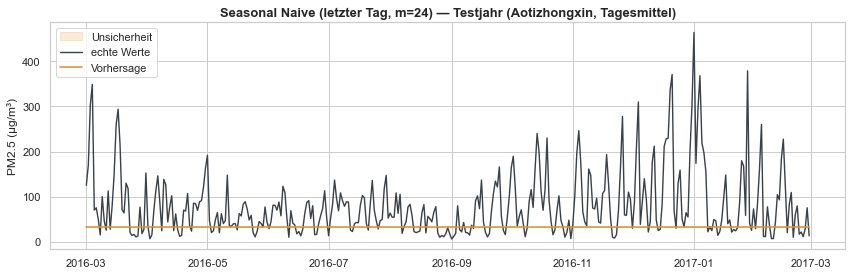

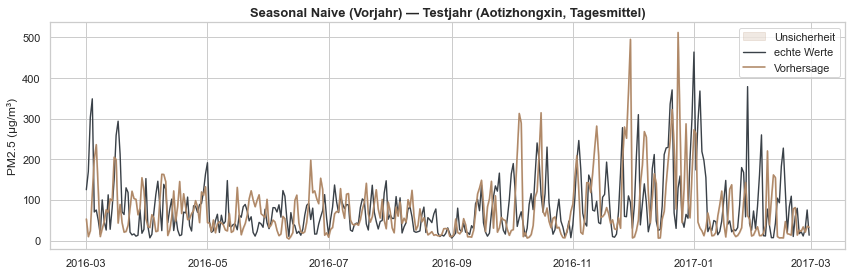

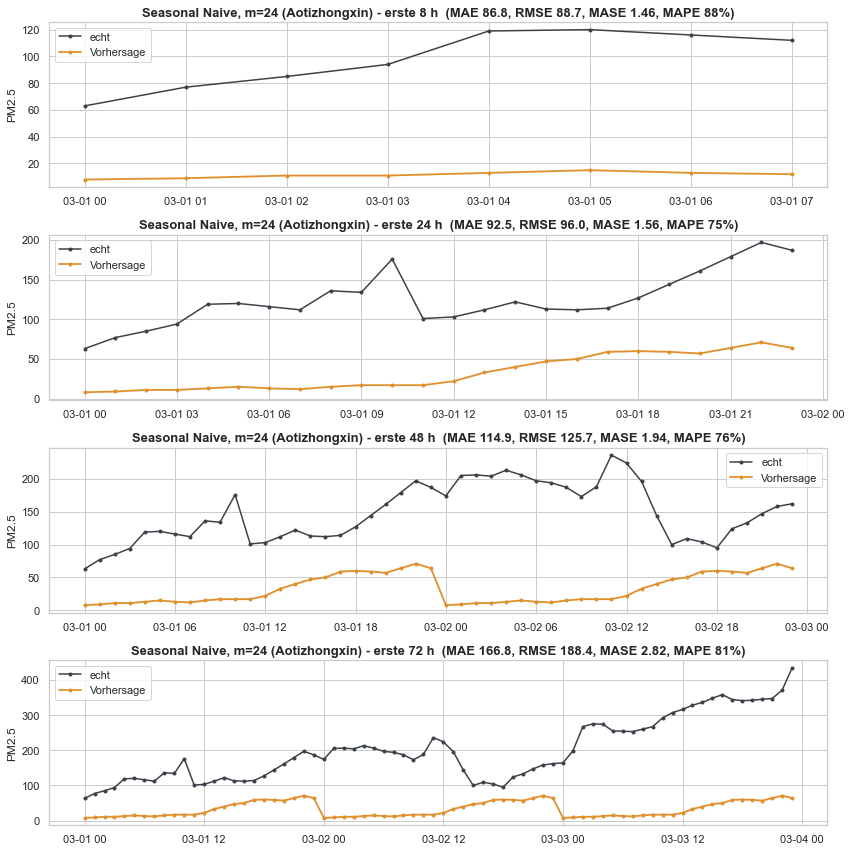

In [8]:
plot_forecast(baseline_out,    f"Seasonal Naive (letzter Tag, m=24) — Testjahr ({STATION}, Tagesmittel)", farbe=AMBER)
plot_forecast(baseline_vj_out, f"Seasonal Naive (Vorjahr) — Testjahr ({STATION}, Tagesmittel)", farbe="#B08968")
plot_horizonte(baseline_out, f"Seasonal Naive, m=24 ({STATION})", SKALA, farbe=AMBER)

## 7. Detail-Analyse für eine Station: Baseline + 5 Prophet-Stufen

Wir lassen für `STATION` die komplette Konfigurations-Leiter laufen und vergleichen sie — zusammen mit den beiden Seasonal-Naive-Baselines aus Abschnitt 6 — über alle vier Fehlermaße.

**Warum Feiertage schon als Stufe 2?** Rund um das **Frühlingsfest** ändern sich Verkehr, Industrie und vor allem das **Feuerwerk** — Kapitel 01 (Abschnitt 8) zeigt Peaks bis fast 700 µg/m³ in den ersten Neujahrsstunden. Das ist ein reiner Kalender-Effekt, den Prophet über `add_country_holidays("CN")` lernen *könnte* — deshalb testen wir ihn als eigene Stufe, noch bevor Wetter-Regressoren ins Spiel kommen.

> ⚠️ **Was die Ergebnisse tatsächlich zeigen (Spoiler):** Die Feiertage **allein** verbessern das Modell **nicht** — in der Tabelle unten liegt „Basis + Feiertage" sogar minimal *schlechter* als „Basis (univariat)". Der Grund: Das Trainingsfenster enthält nur wenige Neujahrs-Feste, das reicht Prophet nicht, um einen stabilen, verallgemeinerbaren Feiertagseffekt zu schätzen; über das ganze Testjahr überwiegt das Rauschen. Der große Sprung kommt erst durch die **Wetter-Regressoren** und die **behandelten Daten**. Ein ehrliches, lehrreiches Ergebnis: *eingebautes Fachwissen hilft nur, wenn genug Daten den Effekt tragen.*

> 🔍 **Hinweis zur Stufe Behandelt (inzwischen korrigiert):** Die behandelte Variante kappt Ausreißer auf das 99,9-Perzentil des Trainings — aber **nur im Training**; die **Test-Zielwerte bleiben echt** (Notebook 02, Abschnitt 10). Das Entkappen der Testwerte hat den Fehler nur **minimal** verändert (Stationsmittel-RMSE 74,1 -> 74,6; MASE unverändert 0,84). Der Sprung von Basis+Reg (RMSE 90,9) auf Behandelt+Reg (74,6) ist damit ein **echter** Modellgewinn durch sauberere Trainingsdaten — kein Artefakt eines leichteren Ziels.

> ⏱️ **Laufzeit:** Jeder Fit auf ~26.000 Stundenwerten dauert **~10–30 Sekunden**, die fünf Läufe zusammen ca. **1–3 Minuten**. Die Baselines kosten praktisch keine Rechenzeit.

In [9]:
# Konfigurations-Leiter: jede Stufe fuegt genau einen Baustein hinzu
konfigs = {
    "Basis (univariat)":                   dict(variante="basis",     regressoren=[],          log=False),
    "Basis + Feiertage":                   dict(variante="basis",     regressoren=[],          log=False, feiertage="CN"),
    "Basis + Feiertage + Regressoren":     dict(variante="basis",     regressoren=REGRESSOREN, log=False, feiertage="CN"),
    "Behandelt + Feiertage + Regressoren": dict(variante="behandelt", regressoren=REGRESSOREN, log=False, feiertage="CN"),
    "Behandelt + FT + Reg + Log":          dict(variante="behandelt", regressoren=REGRESSOREN, log=True,  feiertage="CN"),
}

# Die beiden Baselines aus Abschnitt 6 laufen als Referenz in der Tabelle mit
modelle = {}
ergebnisse = {"Seasonal Naive (Baseline)": baseline_out,
              "Seasonal Naive (Vorjahr)":  baseline_vj_out}
zeilen = [{"Konfiguration": "Seasonal Naive (Baseline)", **jahres_fehler(baseline_out, SKALA)},
          {"Konfiguration": "Seasonal Naive (Vorjahr)",  **jahres_fehler(baseline_vj_out, SKALA)}]

for name, cfg in konfigs.items():
    tr, te = lade(cfg["variante"])
    m, fc, out = fit_predict(tr, te, regressoren=cfg["regressoren"], log=cfg["log"],
                             feiertage=cfg.get("feiertage"))
    modelle[name], ergebnisse[name] = (m, fc), out
    zeilen.append({"Konfiguration": name, **jahres_fehler(out, SKALA)})
    print(f"fertig: {name}")

metriken = pd.DataFrame(zeilen)
print(); print(metriken.to_string(index=False))

03:42:34 - cmdstanpy - INFO - Chain [1] start processing
03:42:41 - cmdstanpy - INFO - Chain [1] done processing


fertig: Basis (univariat)


03:42:46 - cmdstanpy - INFO - Chain [1] start processing
03:43:02 - cmdstanpy - INFO - Chain [1] done processing


fertig: Basis + Feiertage


03:43:08 - cmdstanpy - INFO - Chain [1] start processing
03:43:28 - cmdstanpy - INFO - Chain [1] done processing


fertig: Basis + Feiertage + Regressoren


03:43:34 - cmdstanpy - INFO - Chain [1] start processing
03:43:44 - cmdstanpy - INFO - Chain [1] done processing


fertig: Behandelt + Feiertage + Regressoren


03:43:49 - cmdstanpy - INFO - Chain [1] start processing
03:44:00 - cmdstanpy - INFO - Chain [1] done processing


fertig: Behandelt + FT + Reg + Log

                      Konfiguration       MAE       RMSE     MASE     MAPE %
          Seasonal Naive (Baseline) 63.585869  98.547642 1.073493 120.621261
           Seasonal Naive (Vorjahr) 73.138309 107.526122 1.234762 239.248257
                  Basis (univariat) 78.825579 114.018084 1.330778  97.473757
                  Basis + Feiertage 79.710637 115.218391 1.345720  98.933767
    Basis + Feiertage + Regressoren 59.188536  86.288455 0.999254  85.441101
Behandelt + Feiertage + Regressoren 40.284780  62.407342 0.680110 105.891819
         Behandelt + FT + Reg + Log 39.939698  67.297416 0.674285  67.940905


**Fehlermaße im Vergleich** (kleiner = besser; bei MASE markiert die gestrichelte Linie 1.0 das Niveau der Baseline — nur darunter lohnt sich ein Modell):

> 📌 **So liest man die Balken — Nutzen in der richtigen Reihenfolge:** **Feiertage** verschieben kaum etwas (teils leicht schlechter), die **Wetter-Regressoren** bringen den ersten großen Sprung, die **behandelten Daten** den zweiten (teils durch das leichtere Ziel, siehe Hinweis oben), das **Log-Ziel** senkt vor allem den MAPE. Erst ab „Basis + Feiertage + Regressoren" fällt MASE unter 1 — ab da schlägt das Modell die naive Baseline übers ganze Jahr.

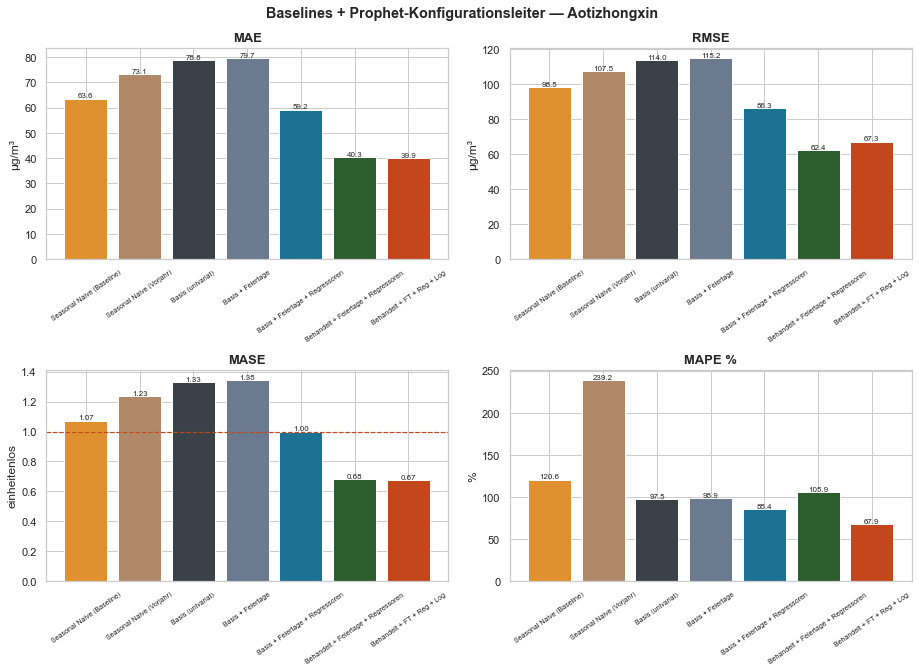

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9.5))
farben = [AMBER, "#B08968", SLATE, "#6B7A8F", TEAL, MOSS, RUST][:len(metriken)]
einheiten = {"MAE": "µg/m³", "RMSE": "µg/m³", "MASE": "einheitenlos", "MAPE %": "%"}

for ax, metrik in zip(axes.ravel(), ["MAE", "RMSE", "MASE", "MAPE %"]):
    bars = ax.bar(metriken["Konfiguration"], metriken[metrik], color=farben)
    ax.set_title(metrik); ax.set_ylabel(einheiten[metrik])
    ax.tick_params(axis="x", rotation=35, labelsize=7)
    fmt = "{:.2f}" if metrik == "MASE" else "{:.1f}"
    for b, v in zip(bars, metriken[metrik]):
        ax.text(b.get_x()+b.get_width()/2, v, fmt.format(v), ha="center", va="bottom", fontsize=8)
    if metrik == "MASE":
        ax.axhline(1.0, color=RUST, lw=1.2, ls="--")   # 1.0 = Niveau der Baseline

plt.suptitle(f"Baselines + Prophet-Konfigurationsleiter — {STATION}", fontweight="bold")
plt.tight_layout(); plt.show()

**Vorhersage vs. echte Werte** für die beste Prophet-Konfiguration (nach RMSE):

Beste Prophet-Konfiguration nach RMSE: Behandelt + Feiertage + Regressoren


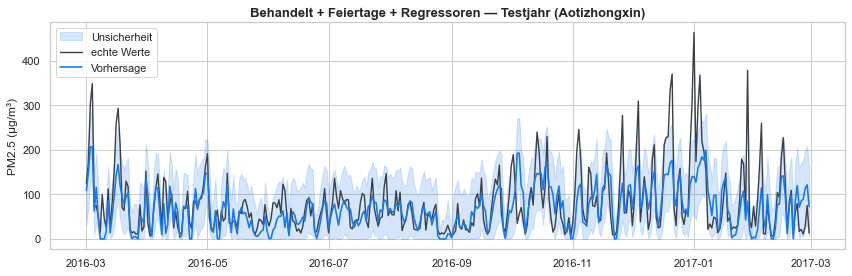

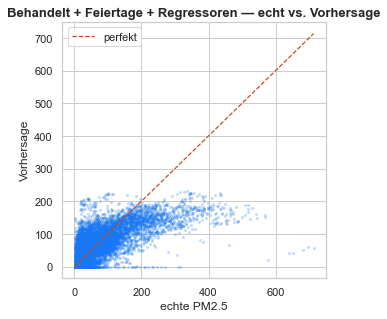

In [11]:
baseline_namen = ["Seasonal Naive (Baseline)", "Seasonal Naive (Vorjahr)"]
prophet_only = metriken[~metriken["Konfiguration"].isin(baseline_namen)]
bestname = prophet_only.sort_values("RMSE").iloc[0]["Konfiguration"]
print("Beste Prophet-Konfiguration nach RMSE:", bestname)
plot_forecast(ergebnisse[bestname], f"{bestname} — Testjahr ({STATION})")
plot_scatter(ergebnisse[bestname], f"{bestname} — echt vs. Vorhersage")

**Prophet-Komponenten** der besten Konfiguration (Trend, Jahres-, Wochen-, Tagesmuster).

> Hinweis: Wenn die beste Konfiguration das **Log-Ziel** nutzt, sind diese Komponenten auf der **log-Skala** dargestellt.

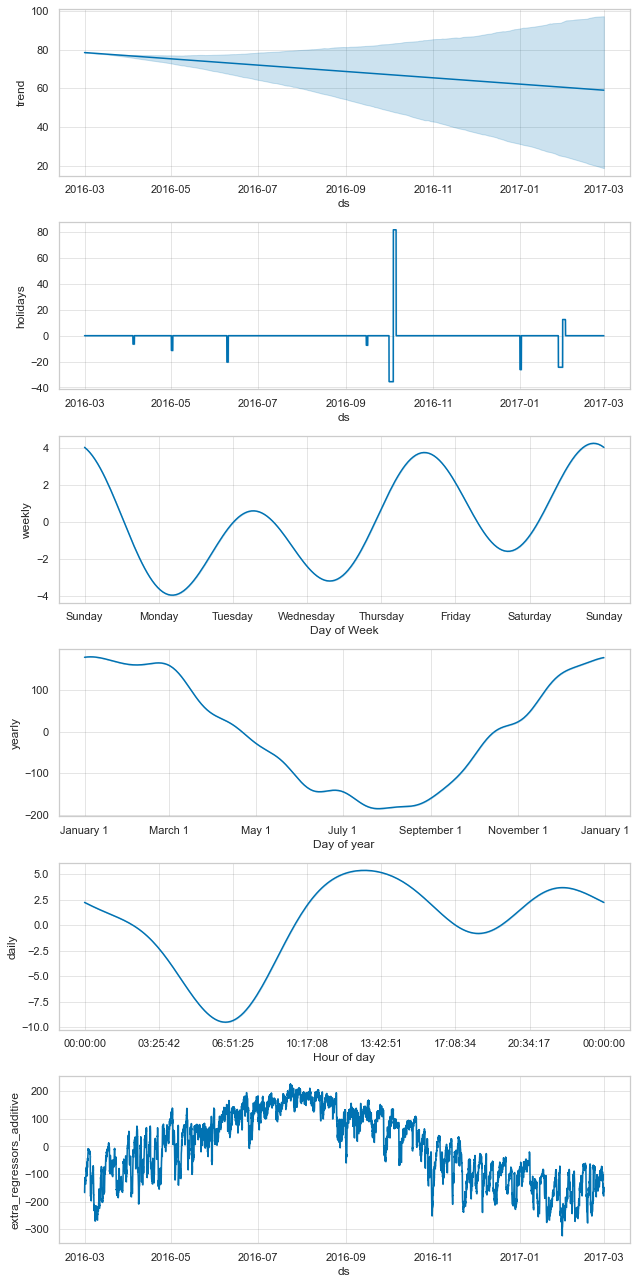

In [12]:
m_best, fc_best = modelle[bestname]
fig = m_best.plot_components(fc_best); plt.show()

### Kurzfristige Prognose: 8 / 24 / 48 / 72 Stunden (stündliche Auflösung)

Für die Praxis zählt oft die **kurzfristige** Güte. Wir zeigen die ersten 8, 24, 48 und 72 Stunden des Testzeitraums
in **stündlicher** Auflösung (nicht geglättet), berechnen die Fehler je Zeitfenster und stellen sie der Baseline gegenüber.

> ⚠️ **Diese Zahlen sind _ein einziger_ Startpunkt (1.3.2016) — nicht repräsentativ.** Die hier sichtbaren Traum-Werte (8-h-MASE ≈ 0,18) entstehen, weil der 1.3.2016 zufällig eine „leichte" Wetterlage war. Wie gut das Modell *im Schnitt* kurzfristig ist, zeigt erst das **rollierende Backtesting in Abschnitt 10** über viele Startpunkte quer durchs Jahr — dort liegt der 8-h-MASE bei **≈ 1,0**, also praktisch auf Baseline-Niveau. **Für die Präsentation die rollierenden Zahlen als Kernaussage nehmen, nicht diese hier.**

Kurzfrist-Fehler - Behandelt + Feiertage + Regressoren (Aotizhongxin):
   Horizont       MAE      RMSE     MASE     MAPE %
        8 h 10.374485 11.310566 0.175148  10.848931
       24 h 22.355681 29.757217 0.377421  15.881497
       48 h 33.231661 40.000508 0.561036  20.967284
       72 h 54.145708 68.272044 0.914118  24.052399
ganzes Jahr 40.284780 62.407342 0.680110 105.891819

Zum Vergleich - Seasonal Naive (Baseline, m=24):
   Horizont        MAE       RMSE     MASE     MAPE %
        8 h  86.750000  88.659461 1.464563  88.203052
       24 h  92.500000  95.973521 1.561637  75.174069
       48 h 114.895833 125.721501 1.939736  75.803754
       72 h 166.763889 188.372230 2.815402  80.552856
ganzes Jahr  63.585869  98.547642 1.073493 120.621261

Zum Vergleich - Seasonal Naive (Vorjahr):
   Horizont        MAE       RMSE     MASE     MAPE %
        8 h  32.250000  36.231892 0.544463  31.204750
       24 h  73.375000  91.196039 1.238758  53.590357
       48 h 116.895833 133.990922 1.97

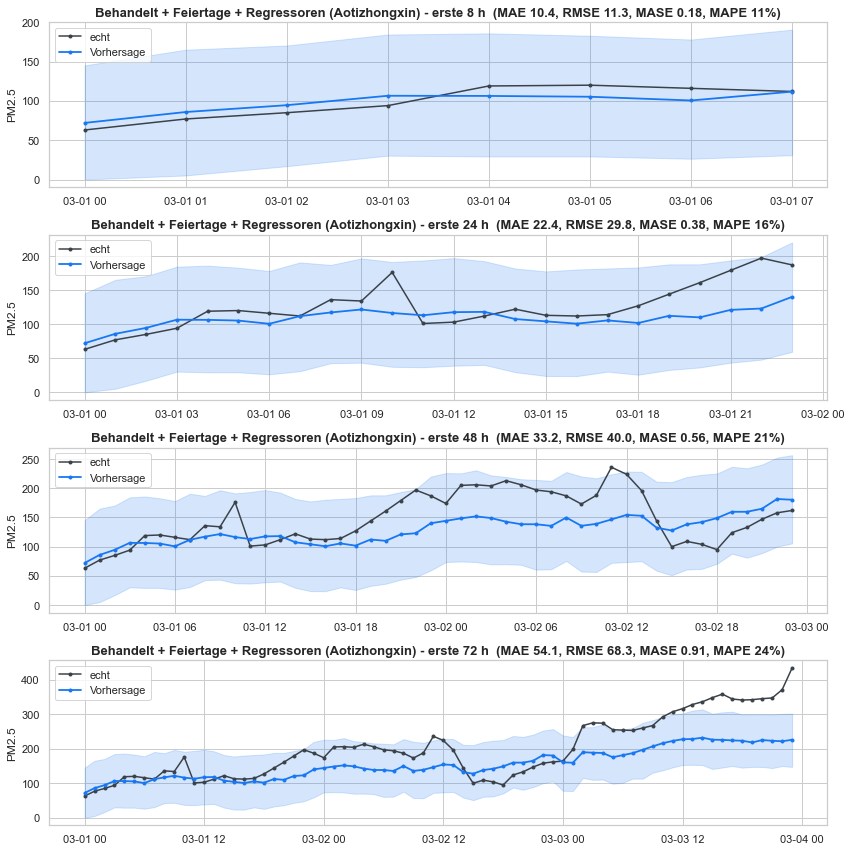

In [13]:
print(f"Kurzfrist-Fehler - {bestname} ({STATION}):")
print(fehler_horizonte(ergebnisse[bestname], SKALA).to_string(index=False))
print()
print("Zum Vergleich - Seasonal Naive (Baseline, m=24):")
print(fehler_horizonte(baseline_out, SKALA).to_string(index=False))
print()
print("Zum Vergleich - Seasonal Naive (Vorjahr):")
print(fehler_horizonte(baseline_vj_out, SKALA).to_string(index=False))

plot_horizonte(ergebnisse[bestname], f"{bestname} ({STATION})", SKALA)

## 8. Erweiterung auf alle 12 Stationen

Jetzt lassen wir die **komplette Leiter** über **alle Stationen** laufen und mitteln die Fehlermaße: die beiden Seasonal-Naive-Baselines plus alle fünf Prophet-Stufen.
Für jede Station und Konfiguration werden alle vier Fehlermaße gespeichert — fürs ganze Testjahr und je Horizont (8/24/48/72 h). Zusätzlich sammeln wir die **Vorhersage-Verläufe** je Station, um sie anschließend im Stadt-Mittel darzustellen.

> ⏱️ **Laufzeit:** 12 Stationen × 5 Prophet-Konfigurationen = **60 Fits** → grob **15–30 Minuten** (die Baselines rechnen in Sekunden).
Zum Ausprobieren erst mit `SCHNELLTEST = True` (nur 2 Stationen) starten!

In [14]:
import time

SCHNELLTEST = False    # False = alle 12 Stationen (voller Lauf); True = nur die ersten 2 (schnell testen)

# dieselbe Konfigurations-Leiter wie in Abschnitt 7
sweep_konfigs = {
    "Basis (univariat)":                   dict(variante="basis",     regressoren=[],          log=False),
    "Basis + Feiertage":                   dict(variante="basis",     regressoren=[],          log=False, feiertage="CN"),
    "Basis + Feiertage + Regressoren":     dict(variante="basis",     regressoren=REGRESSOREN, log=False, feiertage="CN"),
    "Behandelt + Feiertage + Regressoren": dict(variante="behandelt", regressoren=REGRESSOREN, log=False, feiertage="CN"),
    "Behandelt + FT + Reg + Log":          dict(variante="behandelt", regressoren=REGRESSOREN, log=True,  feiertage="CN"),
}
BASELINE_NAMEN = ["Seasonal Naive (Baseline)", "Seasonal Naive (Vorjahr)"]
REIHENFOLGE = BASELINE_NAMEN + list(sweep_konfigs)
SWEEP_FARBEN = [AMBER, "#B08968", SLATE, "#6B7A8F", TEAL, MOSS, RUST]

stationen = sorted(p.name.replace("prophet_train_", "").replace(".csv", "")
                   for p in (PREP / "basis").glob("prophet_train_*.csv"))
if SCHNELLTEST:
    stationen = stationen[:2]
print(f"{len(stationen)} Station(en): {stationen}")

resultate = []
verlaeufe = {name: [] for name in sweep_konfigs}   # Vorhersage-Verlaeufe je Konfiguration sammeln
for st in stationen:
    tr_b, te_b = lade("basis", station=st)
    skala_st = mase_skala(tr_b["y"])                 # MASE-Skala je Station

    # 1) Baselines: Seasonal Naive in beiden Varianten (rechnen in < 1 s)
    resultate.append({"Station": st, "Konfiguration": "Seasonal Naive (Baseline)",
                      **sweep_zeile(seasonal_naive(tr_b, te_b), skala_st)})
    resultate.append({"Station": st, "Konfiguration": "Seasonal Naive (Vorjahr)",
                      **sweep_zeile(seasonal_naive_vorjahr(tr_b, te_b), skala_st)})

    # 2) Prophet-Konfigurationsleiter
    for name, cfg in sweep_konfigs.items():
        t0 = time.time()
        tr, te = lade(cfg["variante"], station=st)
        _, _, out = fit_predict(tr, te, regressoren=cfg["regressoren"], log=cfg["log"],
                                feiertage=cfg.get("feiertage"))
        resultate.append({"Station": st, "Konfiguration": name, **sweep_zeile(out, skala_st)})
        verlaeufe[name].append(out[["ds", "y", "yhat", "yhat_lower", "yhat_upper"]].assign(Station=st))
        print(f"  {st:14s} | {name:36s} | {time.time()-t0:5.0f}s")

ergebnis_alle = pd.DataFrame(resultate)
ergebnis_alle.to_csv("../data/prophet_ergebnisse_stationen.csv", index=False)
print("\ngespeichert: ../data/prophet_ergebnisse_stationen.csv")

12 Station(en): ['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong']


03:44:05 - cmdstanpy - INFO - Chain [1] start processing
03:44:12 - cmdstanpy - INFO - Chain [1] done processing


  Aotizhongxin   | Basis (univariat)                    |    10s


03:44:17 - cmdstanpy - INFO - Chain [1] start processing
03:44:32 - cmdstanpy - INFO - Chain [1] done processing


  Aotizhongxin   | Basis + Feiertage                    |    20s


...

  Wanshouxigong  | Basis + Feiertage + Regressoren      |    28s


04:02:23 - cmdstanpy - INFO - Chain [1] start processing
04:02:39 - cmdstanpy - INFO - Chain [1] done processing


  Wanshouxigong  | Behandelt + Feiertage + Regressoren  |    22s


04:02:45 - cmdstanpy - INFO - Chain [1] start processing
04:03:02 - cmdstanpy - INFO - Chain [1] done processing


  Wanshouxigong  | Behandelt + FT + Reg + Log           |    23s

gespeichert: ../data/prophet_ergebnisse_stationen.csv


**Fehlermaße je Station** (alle sieben Konfigurationen nebeneinander):

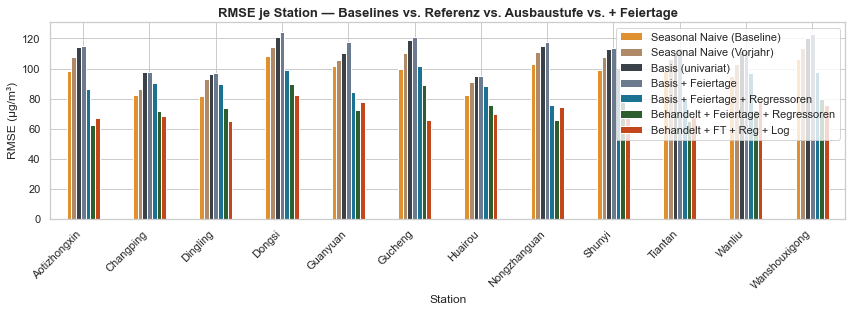

In [15]:
pivot = ergebnis_alle.pivot(index="Station", columns="Konfiguration", values="RMSE")[REIHENFOLGE]
pivot.plot(kind="bar", figsize=(12, 4.5), color=SWEEP_FARBEN)
plt.ylabel("RMSE (µg/m³)"); plt.title("RMSE je Station — Baselines vs. Referenz vs. Ausbaustufe vs. + Feiertage")
plt.xticks(rotation=45, ha="right"); plt.legend(title="", loc="best"); plt.tight_layout(); plt.show()

**Durchschnitt über alle gerechneten Stationen** (alle vier Fehlermaße, ganzes Testjahr):

In [16]:
zusammen = (ergebnis_alle.groupby("Konfiguration")[["MAE", "RMSE", "MASE", "MAPE %"]]
            .mean().round(2).reindex(REIHENFOLGE))
print(zusammen.to_string())

                                       MAE    RMSE  MASE  MAPE %
Konfiguration                                                   
Seasonal Naive (Baseline)            62.03   96.36  1.06  122.07
Seasonal Naive (Vorjahr)             70.88  104.20  1.21  246.65
Basis (univariat)                    75.85  110.24  1.29   97.75
Basis + Feiertage                    77.44  112.36  1.32   99.10
Basis + Feiertage + Regressoren      62.26   90.86  1.07   90.03
Behandelt + Feiertage + Regressoren  49.09   74.63  0.84   87.62
Behandelt + FT + Reg + Log           42.80   71.92  0.73   65.43


**Fehler nach Horizont** (Mittel über alle Stationen):

Zeigt, wie der Fehler mit dem Vorhersage-Horizont wächst — von 8 h über 24/48/72 h bis zum ganzen Testjahr.
Links RMSE (absolut, in µg/m³), rechts MASE (relativ zur Baseline; unter der gestrichelten 1.0-Linie ist ein Modell besser als Seasonal Naive).

RMSE nach Horizont (Mittel ueber alle Stationen):
                                       8 h   24 h    48 h    72 h  ganzes Jahr
Konfiguration                                                                 
Seasonal Naive (Baseline)            79.87  84.92  114.18  170.17        96.36
Seasonal Naive (Vorjahr)             31.95  87.06  126.65  180.57       104.20
Basis (univariat)                    52.65  81.27  109.29  169.29       110.24
Basis + Feiertage                    62.80  91.89  119.79  179.04       112.36
Basis + Feiertage + Regressoren      22.43  36.74   47.15   75.10        90.86
Behandelt + Feiertage + Regressoren  15.68  29.96   41.12   68.51        74.63
Behandelt + FT + Reg + Log           47.95  61.51   70.28   71.96        71.92

MASE nach Horizont (Mittel ueber alle Stationen, < 1 = besser als Baseline):
                                      8 h  24 h  48 h  72 h  ganzes Jahr
Konfiguration                                                           
Seasonal Naive 

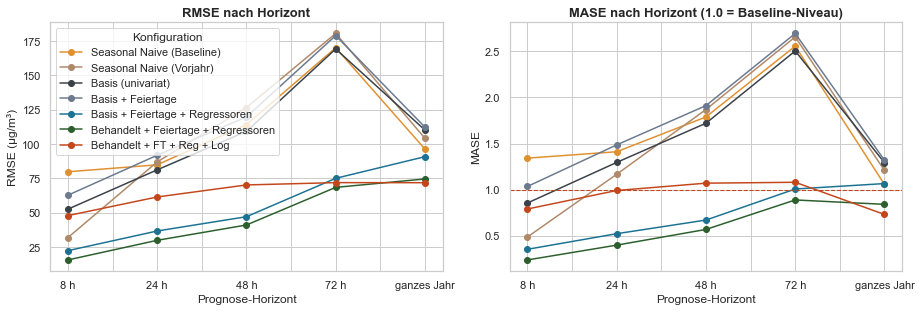

In [17]:
spalten_rmse = {"8 h": "RMSE_8h", "24 h": "RMSE_24h", "48 h": "RMSE_48h", "72 h": "RMSE_72h", "ganzes Jahr": "RMSE"}
spalten_mase = {"8 h": "MASE_8h", "24 h": "MASE_24h", "48 h": "MASE_48h", "72 h": "MASE_72h", "ganzes Jahr": "MASE"}

horizont_rmse = ergebnis_alle.groupby("Konfiguration")[list(spalten_rmse.values())].mean().reindex(REIHENFOLGE)
horizont_rmse.columns = list(spalten_rmse.keys())
horizont_mase = ergebnis_alle.groupby("Konfiguration")[list(spalten_mase.values())].mean().reindex(REIHENFOLGE)
horizont_mase.columns = list(spalten_mase.keys())

print("RMSE nach Horizont (Mittel ueber alle Stationen):")
print(horizont_rmse.round(2).to_string()); print()
print("MASE nach Horizont (Mittel ueber alle Stationen, < 1 = besser als Baseline):")
print(horizont_mase.round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
horizont_rmse.T.plot(marker="o", ax=axes[0], color=SWEEP_FARBEN)
axes[0].set_ylabel("RMSE (µg/m³)"); axes[0].set_xlabel("Prognose-Horizont"); axes[0].set_title("RMSE nach Horizont")
horizont_mase.T.plot(marker="o", ax=axes[1], color=SWEEP_FARBEN, legend=False)
axes[1].axhline(1.0, color=RUST, lw=1.1, ls="--")
axes[1].set_ylabel("MASE"); axes[1].set_xlabel("Prognose-Horizont"); axes[1].set_title("MASE nach Horizont (1.0 = Baseline-Niveau)")
plt.tight_layout(); plt.show()

### Datenverlauf im Stadt-Mittel: echt vs. Vorhersage (8 / 24 / 48 / 72 h + ganzes Jahr)

Zum Schluss der genaue **Datenverlauf über alle 12 Stationen zusammen**: Wir mitteln je Stunde die echten Werte und die Vorhersagen aller Stationen (Stadt-Mittel) — gezeigt wird die **beste Prophet-Konfiguration nach mittlerem RMSE**.

- Die ersten **8 / 24 / 48 / 72 Stunden** ab Testbeginn (1.3.2016) in stündlicher Auflösung,
- das **ganze Testjahr** als Tagesmittel — mit markiertem **chinesischen Neujahr (28.1.2017)**, dem Feuerwerks-Termin aus Kapitel 01.

Für die MASE-Angaben nutzen wir die Skala der Stadt-Mittel-Zeitreihe (gleiche m=24-Logik, berechnet auf dem Stadt-Mittel der Trainingsdaten).

In [18]:
# beste Konfiguration nach mittlerem RMSE (nur Prophet-Stufen, ohne Baselines)
best_sweep = (ergebnis_alle[~ergebnis_alle["Konfiguration"].isin(BASELINE_NAMEN)]
              .groupby("Konfiguration")["RMSE"].mean().idxmin())
print("Beste Konfiguration im Stationsmittel (RMSE):", best_sweep)

# Stadt-Mittel des Verlaufs: je Stunde ueber alle Stationen mitteln
stadt = (pd.concat(verlaeufe[best_sweep])
           .groupby("ds")[["y", "yhat", "yhat_lower", "yhat_upper"]]
           .mean().reset_index())

# MASE-Skala der Stadt-Mittel-Reihe (Trainingsdaten, m=24)
stadt_train = (pd.concat([lade("basis", station=st)[0][["ds", "y"]] for st in stationen])
                 .groupby("ds")["y"].mean().sort_index())
STADT_SKALA = mase_skala(stadt_train)
print(f"MASE-Skala Stadt-Mittel (Training, m=24): {STADT_SKALA:.2f} µg/m³\n")

print(f"Fehlermaße Stadt-Mittel - {best_sweep}:")
print(fehler_horizonte(stadt, STADT_SKALA).to_string(index=False))

Beste Konfiguration im Stationsmittel (RMSE): Behandelt + FT + Reg + Log
MASE-Skala Stadt-Mittel (Training, m=24): 54.34 µg/m³

Fehlermaße Stadt-Mittel - Behandelt + FT + Reg + Log:
   Horizont       MAE      RMSE     MASE    MAPE %
        8 h 46.107014 46.462702 0.848524 50.931042
       24 h 57.840729 60.408808 1.064464 50.080805
       48 h 60.603444 67.288988 1.115307 43.493589
       72 h 60.907685 67.349557 1.120906 36.659927
ganzes Jahr 40.283174 66.653921 0.741346 51.307351


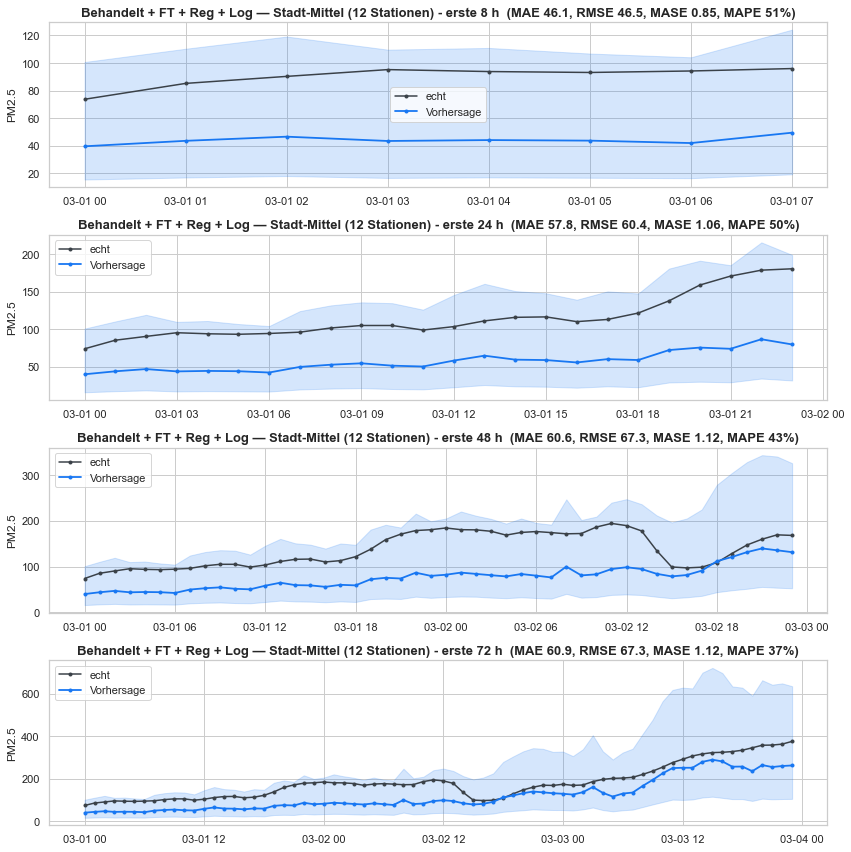

In [19]:
# stundengenauer Verlauf der ersten 8 / 24 / 48 / 72 h (Stadt-Mittel)
plot_horizonte(stadt, f"{best_sweep} — Stadt-Mittel (12 Stationen)", STADT_SKALA, farbe=FBBLAU)

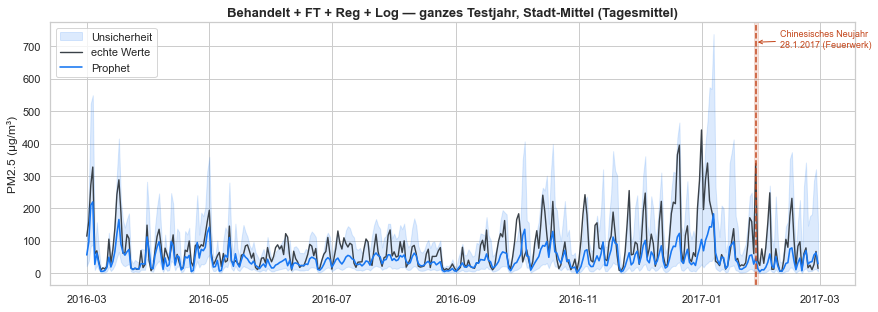

In [20]:
# ganzes Testjahr als Tagesmittel, mit markiertem chinesischen Neujahr
CNY_TEST = pd.Timestamp("2017-01-28")     # Neujahrsfest im Testjahr (Feuerwerk um Mitternacht)

g = stadt.set_index("ds").resample("1D").mean()
plt.figure(figsize=(12.5, 4.5))
plt.fill_between(g.index, g["yhat_lower"], g["yhat_upper"], color=FBBLAU, alpha=0.15, label="Unsicherheit")
plt.plot(g.index, g["y"], color=SLATE, lw=1.4, label="echte Werte")
plt.plot(g.index, g["yhat"], color=FBBLAU, lw=1.6, label="Prophet")
plt.axvspan(CNY_TEST - pd.Timedelta(days=1), CNY_TEST + pd.Timedelta(days=1), color=RUST, alpha=0.15)
plt.axvline(CNY_TEST, color=RUST, ls="--", lw=1.5)
plt.annotate("Chinesisches Neujahr\n28.1.2017 (Feuerwerk)", xy=(CNY_TEST, plt.ylim()[1]*0.92),
             xytext=(CNY_TEST + pd.Timedelta(days=12), plt.ylim()[1]*0.9),
             color=RUST, fontsize=9, arrowprops=dict(arrowstyle="->", color=RUST))
plt.ylabel("PM2.5 (µg/m³)")
plt.title(f"{best_sweep} — ganzes Testjahr, Stadt-Mittel (Tagesmittel)")
plt.legend(loc="best"); plt.tight_layout(); plt.show()

## 9. Hyperparameter-Tuning: `changepoint_prior_scale` & Saisonalität

Prophet hat zwei besonders einflussreiche Stellschrauben (siehe Prophet-Dokumentation, Abschnitt *Hyperparameter tuning*, https://facebook.github.io/prophet/docs/diagnostics.html):

| Parameter | Standard | Wirkung |
|---|---|---|
| `changepoint_prior_scale` | 0.05 | Flexibilität des **Trends**. Zu groß → der Trend folgt jedem Zucken (Overfitting); zu klein → der Trend ist zu starr und verpasst echte Niveauwechsel. |
| `seasonality_prior_scale` | 10 | Stärke der **Saisonalitäten** (Jahres-, Wochen-, Tagesmuster). Kleine Werte dämpfen die Saisonmuster, große lassen sie frei schwingen. |

**Wichtig — kein Tuning auf dem Test-Set!** Wer Parameter am Testjahr optimiert, bekommt geschönte Fehlerwerte (Leakage). Deshalb teilen wir das **Training** noch einmal auf: Die letzten 12 Monate des Trainings (März 2015 – Februar 2016) werden zum **Validierungs-Set**. Ablauf:

1. Grid-Search auf Tuning-Training → Validierung (9 Kombinationen),
2. beste Parameter final auf dem **kompletten Training** fitten,
3. **einmalige** Bewertung auf dem unberührten Testjahr — fair vergleichbar mit Abschnitt 7.

Getunt wird die beste Konfiguration aus Abschnitt 7 (`bestname`). Prophet bietet für gründlicheres Tuning auch `prophet.diagnostics.cross_validation` (rollierendes Backtesting) — deutlich rechenintensiver, daher hier die schlanke Holdout-Variante.

> ⏱️ **Laufzeit:** 9 Validierungs-Fits + 1 finaler Fit ≈ **3–6 Minuten**. Das Grid lässt sich in `GRID` beliebig erweitern.

In [21]:
import time
import itertools

GRID = {
    "changepoint_prior_scale": [0.01, 0.05, 0.5],    # Standard: 0.05
    "seasonality_prior_scale": [0.1, 1.0, 10.0],     # Standard: 10
}

# Validierungs-Split INNERHALB des Trainings (leakage-frei; Testjahr bleibt unberuehrt)
cfg_best = konfigs[bestname]
tr_voll, te_test = lade(cfg_best["variante"])
split = tr_voll["ds"].max() - pd.DateOffset(years=1)
tr_tune  = tr_voll[tr_voll["ds"] <= split].reset_index(drop=True)
val_tune = tr_voll[tr_voll["ds"] >  split].reset_index(drop=True)
skala_tune = mase_skala(tr_tune["y"])
print(f"Konfiguration: {bestname}")
print(f"Tuning-Training bis {split:%d.%m.%Y %H:%M}  |  Validierung: {len(val_tune)} Stunden\n")

tuning = []
for cps, sps in itertools.product(*GRID.values()):
    kwargs = dict(PROPHET_KWARGS, changepoint_prior_scale=cps, seasonality_prior_scale=sps)
    t0 = time.time()
    _, _, out_val = fit_predict(tr_tune, val_tune, regressoren=cfg_best["regressoren"],
                                log=cfg_best["log"], feiertage=cfg_best.get("feiertage"),
                                prophet_kwargs=kwargs)
    tuning.append({"changepoint_prior_scale": cps, "seasonality_prior_scale": sps,
                   **jahres_fehler(out_val, skala_tune)})
    print(f"  cps={cps:<5} sps={sps:<5} ->  RMSE {tuning[-1]['RMSE']:6.1f}  ({time.time()-t0:.0f}s)")

tuning_df = pd.DataFrame(tuning).sort_values("RMSE").reset_index(drop=True)
print(); print(tuning_df.to_string(index=False))

beste_params = {k: tuning_df.iloc[0][k] for k in GRID}
print("\nBeste Parameter (nach Validierungs-RMSE):", beste_params)

Konfiguration: Behandelt + Feiertage + Regressoren
Tuning-Training bis 28.02.2015 23:00  |  Validierung: 8784 Stunden



04:03:09 - cmdstanpy - INFO - Chain [1] start processing
04:03:11 - cmdstanpy - INFO - Chain [1] done processing


  cps=0.01  sps=0.1   ->  RMSE   65.3  (7s)


04:03:16 - cmdstanpy - INFO - Chain [1] start processing
04:03:18 - cmdstanpy - INFO - Chain [1] done processing


  cps=0.01  sps=1.0   ->  RMSE   65.5  (7s)


...

  cps=0.5   sps=0.1   ->  RMSE   88.6  (27s)


04:04:31 - cmdstanpy - INFO - Chain [1] start processing
04:04:56 - cmdstanpy - INFO - Chain [1] done processing


  cps=0.5   sps=1.0   ->  RMSE  105.8  (29s)


04:05:00 - cmdstanpy - INFO - Chain [1] start processing
04:05:22 - cmdstanpy - INFO - Chain [1] done processing


  cps=0.5   sps=10.0  ->  RMSE  110.5  (26s)

 changepoint_prior_scale  seasonality_prior_scale       MAE       RMSE     MASE     MAPE %
                    0.01                     10.0 42.860558  65.254626 0.680342 107.258546
                    0.01                      0.1 42.851398  65.296356 0.680196 106.770843
                    0.01                      1.0 42.846745  65.462069 0.680123 104.948114
                    0.05                     10.0 55.650533  84.239307 0.883362  85.286973
                    0.05                      1.0 55.797041  84.424552 0.885688  85.403569
                    0.50                      0.1 60.871172  88.569814 0.966231  90.020066
                    0.05                      0.1 59.220665  88.874184 0.940032  87.764338
                    0.50                      1.0 72.607772 105.821376 1.152531  98.008321
                    0.50                     10.0 74.671939 110.545173 1.185296  98.846934

Beste Parameter (nach Validierungs-RMSE): {

**Finale Bewertung:** Mit den besten Parametern trainieren wir einmal auf dem kompletten Training und bewerten auf dem Testjahr — direkt neben dem Standard-Lauf aus Abschnitt 7:

04:05:27 - cmdstanpy - INFO - Chain [1] start processing
04:05:34 - cmdstanpy - INFO - Chain [1] done processing


                                        Modell       MAE      RMSE     MASE     MAPE %
Behandelt + Feiertage + Regressoren (Standard) 40.284780 62.407342 0.680110 105.891819
  Behandelt + Feiertage + Regressoren (getunt) 41.457156 61.997639 0.699903 126.141445

Kurzfrist-Fehler (getunt):
   Horizont       MAE      RMSE     MASE     MAPE %
        8 h 10.864729 11.452660 0.183425  11.710741
       24 h 21.788911 28.843913 0.367853  15.705046
       48 h 32.658915 39.130975 0.551366  20.814911
       72 h 53.216424 67.166134 0.898430  23.762091
ganzes Jahr 41.457156 61.997639 0.699903 126.141445


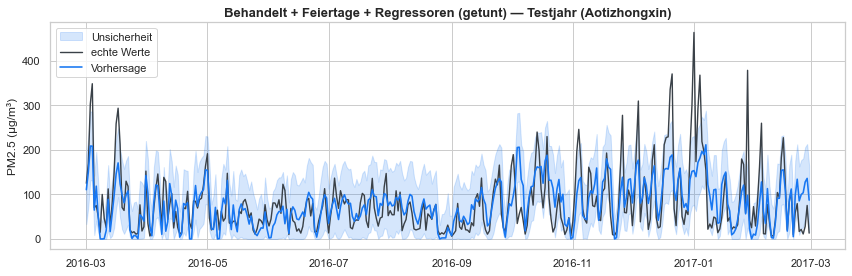

In [22]:
kwargs_getunt = dict(PROPHET_KWARGS, **beste_params)
_, _, out_getunt = fit_predict(tr_voll, te_test, regressoren=cfg_best["regressoren"],
                               log=cfg_best["log"], feiertage=cfg_best.get("feiertage"),
                               prophet_kwargs=kwargs_getunt)

vergleich = pd.DataFrame([
    {"Modell": f"{bestname} (Standard)", **jahres_fehler(ergebnisse[bestname], SKALA)},
    {"Modell": f"{bestname} (getunt)",   **jahres_fehler(out_getunt, SKALA)},
])
print(vergleich.to_string(index=False))
print()
print("Kurzfrist-Fehler (getunt):")
print(fehler_horizonte(out_getunt, SKALA).to_string(index=False))

plot_forecast(out_getunt, f"{bestname} (getunt) — Testjahr ({STATION})")

**Einordnung:** Fällt der Gewinn klein aus, sind die Prophet-Standardwerte für diese Daten bereits gut gewählt — auch das ist ein Ergebnis. Wichtig ist der Blick auf **Validierung vs. Test**: Wenn eine Kombination auf der Validierung stark, auf dem Test aber schwach ist, deutet das auf Überanpassung an den Validierungszeitraum hin. Das Grid lässt sich leicht erweitern (`seasonality_mode="multiplicative"`, `holidays_prior_scale`, weitere Werte) — die Laufzeit wächst multiplikativ mit.

## 10. Rollierendes Backtesting mit `cross_validation`

> 🎯 **Dieser Abschnitt liefert die _repräsentativen_ Kurzfrist-Zahlen** — anders als der einzelne, zufällig günstige Teststart aus Abschnitt 7.


Unsere 8/24/48/72-h-Fehler messen bisher genau **eine** Situation: die ersten Stunden ab dem 1.3.2016. Ob das Modell kurzfristig *generell* gut ist, zeigt erst ein **rollierendes Backtesting** (auch *rolling origin* oder *time series cross-validation*; Hyndman & Athanasopoulos, *FPP*): Der Vorhersage-Startpunkt („Cutoff") wird mehrfach nach vorn geschoben, bei jedem Cutoff wird das Modell **neu gefittet** — nur auf Daten davor, nie auf der Zukunft — und `horizon` Stunden vorhergesagt:

```text
Cutoff 1:  [====== Training ======]→72h
Cutoff 2:  [========= Training =========]→72h
Cutoff 3:  [============ Training ============]→72h
                                   (Zeit →)
```

**Abgrenzung zum Sliding Window:** Prophets `cross_validation` nutzt ein **wachsendes Fenster** (expanding window — Training beginnt immer am Datenanfang und wird je Cutoff länger). Beim klassischen **Sliding Window** hätte das Trainingsfenster feste Länge und würde mitwandern; alte Daten fielen hinten raus. Wachsend ist hier richtig, weil die Jahressaisonalität von jeder zusätzlichen Historie profitiert; gleitend wäre besser, wenn sich das System strukturell ändert (z. B. neue Umweltauflagen).

Die drei Parameter (Prophet-Doku, *Diagnostics*):

| Parameter | hier | Bedeutung |
|---|---|---|
| `initial` | 730 Tage | Mindest-Trainingslänge vor dem ersten Cutoff (2 volle Jahreszyklen) |
| `period` | 30 Tage | Abstand zwischen den Cutoffs |
| `horizon` | 72 h | Vorhersageweite je Cutoff |

Mit unserem 3-Jahres-Training ergibt das **~12 Cutoffs quer durch alle Jahreszeiten** — statt einer einzigen Wettersituation also ein robuster Durchschnitt der Kurzfrist-Güte. Wichtig: Alle Cutoffs liegen **innerhalb des Trainingszeitraums**, das Testjahr bleibt weiterhin unberührt.

> ⏱️ **Laufzeit:** ~12 Fits ≈ **3–6 Minuten**. Läuft auf dem gefitteten Modell der besten Konfiguration aus Abschnitt 7 (`bestname`).

In [23]:
from prophet.diagnostics import cross_validation

m_cv, _ = modelle[bestname]              # gefittetes Modell der besten Konfiguration
cv_log = konfigs[bestname]["log"]        # wurde auf dem Log-Ziel trainiert?

df_cv = cross_validation(m_cv, initial="730 days", period="30 days", horizon="72 hours")
print(f"{df_cv['cutoff'].nunique()} Cutoffs, {len(df_cv)} bewertete Vorhersage-Stunden")

# ggf. von der Log-Skala zurueck nach µg/m³, damit die Fehlermaße vergleichbar bleiben
cv = df_cv.copy()
if cv_log:
    for c in ["y", "yhat", "yhat_lower", "yhat_upper"]:
        cv[c] = np.expm1(cv[c])
cv["yhat"] = cv["yhat"].clip(lower=0)
cv["stunden_voraus"] = ((cv["ds"] - cv["cutoff"]).dt.total_seconds() // 3600).astype(int)

# alle vier Fehlermaße je Horizont — gemittelt ueber ALLE Cutoffs
zeilen_cv = []
for h in HORIZONTE:
    w = cv[cv["stunden_voraus"] <= h]
    zeilen_cv.append({"Horizont": f"{h} h", "MAE": mae(w["y"], w["yhat"]),
                      "RMSE": rmse(w["y"], w["yhat"]),
                      "MASE": mase(w["y"], w["yhat"], SKALA),
                      "MAPE %": mape(w["y"], w["yhat"])})
cv_tab = pd.DataFrame(zeilen_cv)

print(f"\nRollierendes Backtesting - {bestname} ({STATION}, Mittel ueber alle Cutoffs):")
print(cv_tab.to_string(index=False))
print(f"\nZum Vergleich - nur der eine Start am 1.3.2016 (Abschnitt 7):")
print(fehler_horizonte(ergebnisse[bestname], SKALA).head(len(HORIZONTE)).to_string(index=False))

  0%|          | 0/13 [00:00<?, ?it/s]

04:05:39 - cmdstanpy - INFO - Chain [1] start processing
04:05:46 - cmdstanpy - INFO - Chain [1] done processing
04:05:49 - cmdstanpy - INFO - Chain [1] start processing
04:05:56 - cmdstanpy - INFO - Chain [1] done processing
04:06:00 - cmdstanpy - INFO - Chain [1] start processing
04:06:06 - cmdstanpy - INFO - Chain [1] done processing
04:06:10 - cmdstanpy - INFO - Chain [1] start processing
04:06:18 - cmdstanpy - INFO - Chain [1] done processing
04:06:21 - cmdstanpy - INFO - Chain [1] start processing
04:06:28 - cmdstanpy - INFO - Chain [1] done processing
04:06:31 - cmdstanpy - INFO - Chain [1] start processing
04:06:37 - cmdstanpy - INFO - Chain [1] done processing
04:06:41 - cmdstanpy - INFO - Chain [1] start processing
04:06:50 - cmdstanpy - INFO - Chain [1] done processing
04:06:54 - cmdstanpy - INFO - Chain [1] start processing
04:07:02 - cmdstanpy - INFO - Chain [1] done processing
04:07:06 - cmdstanpy - INFO - Chain [1] start processing
04:07:17 - cmdstanpy - INFO - Chain [1]

13 Cutoffs, 936 bewertete Vorhersage-Stunden

Rollierendes Backtesting - Behandelt + Feiertage + Regressoren (Aotizhongxin, Mittel ueber alle Cutoffs):
Horizont       MAE      RMSE     MASE     MAPE %
     8 h 60.574264 76.370574 1.022649 209.128955
    24 h 53.767958 73.604877 0.907741 163.397807
    48 h 56.073190 88.851366 0.946659 170.161540
    72 h 57.653853 95.068194 0.973345 154.564119

Zum Vergleich - nur der eine Start am 1.3.2016 (Abschnitt 7):
Horizont       MAE      RMSE     MASE    MAPE %
     8 h 10.374485 11.310566 0.175148 10.848931
    24 h 22.355681 29.757217 0.377421 15.881497
    48 h 33.231661 40.000508 0.561036 20.967284
    72 h 54.145708 68.272044 0.914118 24.052399


In [24]:
# Repraesentative Kurzfrist-Guete: rollierendes Backtesting vs. der eine Gluecks-Start (1.3.2016)
einzel = fehler_horizonte(ergebnisse[bestname], SKALA).head(len(HORIZONTE)).set_index('Horizont')
roll   = cv_tab.set_index('Horizont')

vergleich_kf = pd.DataFrame({
    'MASE rollierend':  roll['MASE'],
    'MASE Einzelstart': einzel['MASE'],
    'RMSE rollierend':  roll['RMSE'],
    'RMSE Einzelstart': einzel['RMSE'],
})
vergleich_kf['Untertreibung (x)'] = (roll['MASE'] / einzel['MASE']).round(1)   # wie stark der Einzelstart schoent

print(f'Kurzfrist-Guete - {bestname} ({STATION})')
print('rollierend (repraesentativ, alle Cutoffs) vs. Einzelstart 1.3.2016:\n')
print(vergleich_kf.round(2).to_string())
print(f'\nDer Einzelstart untertreibt den Kurzfrist-Fehler um das '
      f"{vergleich_kf['Untertreibung (x)'].min():.0f}- bis {vergleich_kf['Untertreibung (x)'].max():.0f}-fache "
      f'-> in der Praesentation die rollierenden Zahlen zeigen.')

Kurzfrist-Guete - Behandelt + Feiertage + Regressoren (Aotizhongxin)
rollierend (repraesentativ, alle Cutoffs) vs. Einzelstart 1.3.2016:

          MASE rollierend  MASE Einzelstart  RMSE rollierend  RMSE Einzelstart  Untertreibung (x)
Horizont                                                                                         
8 h                  1.02              0.18            76.37             11.31                5.8
24 h                 0.91              0.38            73.60             29.76                2.4
48 h                 0.95              0.56            88.85             40.00                1.7
72 h                 0.97              0.91            95.07             68.27                1.1

Der Einzelstart untertreibt den Kurzfrist-Fehler um das 1- bis 6-fache -> in der Praesentation die rollierenden Zahlen zeigen.


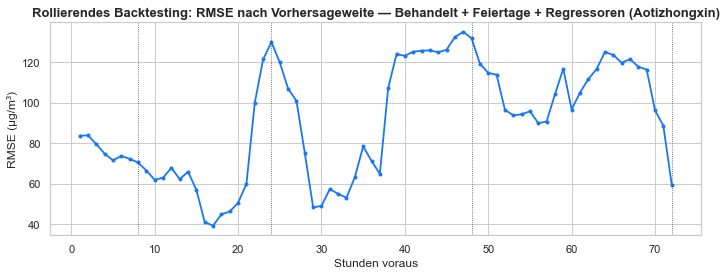

In [25]:
# Fehlerwachstum mit der Vorhersageweite: RMSE je Stunde voraus (Mittel ueber alle Cutoffs)
je_stunde = cv.groupby("stunden_voraus").apply(lambda g: rmse(g["y"], g["yhat"]))

plt.figure(figsize=(10, 4))
plt.plot(je_stunde.index, je_stunde.values, color=FBBLAU, lw=1.8, marker="o", ms=3)
for h in HORIZONTE:
    plt.axvline(h, color=SLATE, lw=0.8, ls=":")
plt.xlabel("Stunden voraus"); plt.ylabel("RMSE (µg/m³)")
plt.title(f"Rollierendes Backtesting: RMSE nach Vorhersageweite — {bestname} ({STATION})")
plt.tight_layout(); plt.show()

**Kernaussage für die Präsentation:** Diese rollierenden Werte (8-h-MASE ca. 1,0, also nahe der naiven Baseline) sind die **ehrlichen** Kurzfrist-Zahlen — der Einzelstart in Abschnitt 7 (8-h-MASE ca. 0,18) war ein Glücksfall. Kurzfristig ist Prophet hier kaum besser als die naive Vortages-Vorhersage; sein echter Mehrwert liegt in der **mittel-/langfristigen** Prognose übers Jahr.

**Einordnung:** Liegen die rollierenden Fehler deutlich über den Werten vom einzelnen Teststart, war der 1.3.2016 eine „leichte" Wetterlage (oder umgekehrt) — genau diese Verzerrung deckt das Backtesting auf. Die Kurve zeigt außerdem, wie schnell die Güte mit der Vorhersageweite abnimmt: typisch steil in den ersten ~24 h, danach flacher. Für Modell-*vergleiche* (Prophet vs. Chronos) bleibt das feste Testjahr die faire Bühne; das rollierende Backtesting beantwortet die Zusatzfrage, wie **stabil** die Kurzfrist-Leistung über verschiedene Startzeitpunkte ist. Mehr Cutoffs = robustere Schätzung: einfach `period` verkleinern (Laufzeit steigt entsprechend); `parallel="processes"` beschleunigt auf Mehrkern-Rechnern.

## 11. Erweitertes Tuning mit rollierendem Backtesting

Abschnitt 9 hat nur zwei Parameter über einen **einfachen Holdout** (ein Validierungsjahr) getunt. Hier gehen wir zwei Schritte weiter:

1. **Größeres Grid** — zusätzlich zur Trend-/Saison-Flexibilität testen wir die **Feiertagsstärke** (`holidays_prior_scale`) und den **Saisonmodus** (`additive` vs. `multiplicative`). Bei Luftschadstoffen mit multiplikativ wirkenden Effekten (Smog-Spitzen skalieren mit dem Niveau) kann `multiplicative` besser passen.
2. **Bewertung über rollierendes Backtesting** statt eines einzigen Holdout-Jahres: Jede Parameter-Kombination wird mit `cross_validation` über mehrere Cutoffs **quer durch das Training** bewertet (leakage-frei, das Testjahr bleibt unberührt). Der mittlere CV-RMSE ist robuster als ein einzelner Holdout.

> ⏱️ **Laufzeit:** Groß! Jede Kombination fittet an mehreren Cutoffs neu. Darum steht `SCHNELL_TUNING = True` als Default (kleines Grid, wenige Cutoffs). Für den vollen Lauf auf `False` setzen und ggf. `parallel="processes"` nutzen.
> 🔒 **Kein Leakage:** Alle Cutoffs liegen im Trainingszeitraum; das Testjahr wird erst ganz am Ende einmal angefasst.

In [26]:
from prophet.diagnostics import cross_validation
import itertools, time

SCHNELL_TUNING = True    # True = kleines Grid + wenige Cutoffs (schnell); False = voller Lauf

if SCHNELL_TUNING:
    GRID2 = {'changepoint_prior_scale': [0.01, 0.05],
             'seasonality_prior_scale': [10.0],
             'holidays_prior_scale':    [10.0],
             'seasonality_mode':        ['additive', 'multiplicative']}
    CV_KW = dict(initial='1000 days', period='90 days', horizon='72 hours')
else:
    GRID2 = {'changepoint_prior_scale': [0.01, 0.05, 0.1],
             'seasonality_prior_scale': [1.0, 10.0],
             'holidays_prior_scale':    [1.0, 10.0],
             'seasonality_mode':        ['additive', 'multiplicative']}
    CV_KW = dict(initial='900 days', period='45 days', horizon='72 hours')

cfg2 = konfigs[bestname]
tr_voll2, te_voll2 = lade(cfg2['variante'])

def cv_rmse(kwargs):
    """Rollierendes Backtesting NUR auf dem Training -> mittlerer RMSE (leakage-frei)."""
    tr = pd.DataFrame({'ds': tr_voll2['ds'].values})
    tr['y'] = np.log1p(tr_voll2['y'].values) if cfg2['log'] else tr_voll2['y'].values
    for r in cfg2['regressoren']:
        tr[r] = tr_voll2[r].values
    m = Prophet(**kwargs)
    if cfg2.get('feiertage'):
        m.add_country_holidays(country_name=cfg2['feiertage'])
    for r in cfg2['regressoren']:
        m.add_regressor(r)
    m.fit(tr)
    dfcv = cross_validation(m, **CV_KW)
    yq = np.expm1(dfcv['yhat']) if cfg2['log'] else dfcv['yhat']
    yt = np.expm1(dfcv['y'])    if cfg2['log'] else dfcv['y']
    return rmse(yt, yq.clip(lower=0)), dfcv['cutoff'].nunique()

print(f'Getunt wird: {bestname}  |  Grid: {np.prod([len(v) for v in GRID2.values()])} Kombinationen')
res2 = []
for combo in itertools.product(*GRID2.values()):
    kw = dict(PROPHET_KWARGS, **dict(zip(GRID2, combo)))
    t0 = time.time(); score, ncut = cv_rmse(kw)
    res2.append({**dict(zip(GRID2, combo)), 'CV_RMSE': round(score, 2)})
    print(f"  cps={combo[0]:<5} sps={combo[1]:<5} hps={combo[2]:<5} mode={combo[3]:<14} "
          f"-> CV-RMSE {score:6.1f}  ({ncut} Cutoffs, {time.time()-t0:.0f}s)")

grid2_df = pd.DataFrame(res2).sort_values('CV_RMSE').reset_index(drop=True)
print(); print(grid2_df.to_string(index=False))
beste2 = {k: grid2_df.iloc[0][k] for k in GRID2}
print('\nBeste Parameter (nach rollierendem CV-RMSE):', beste2)

kw_best2 = dict(PROPHET_KWARGS, **beste2)
_, _, out_best2 = fit_predict(tr_voll2, te_voll2, regressoren=cfg2['regressoren'],
                              log=cfg2['log'], feiertage=cfg2.get('feiertage'), prophet_kwargs=kw_best2)
vergleich11 = pd.DataFrame([
    {'Modell': f'{bestname} (Standard)',  **jahres_fehler(ergebnisse[bestname], SKALA)},
    {'Modell': f'{bestname} (CV-getunt)', **jahres_fehler(out_best2, SKALA)},
])
print('\nEndbewertung auf dem Testjahr:'); print(vergleich11.to_string(index=False))

grid2_df.to_csv('../data/ergebnis_11_tuninggrid.csv', index=False)
vergleich11.to_csv('../data/ergebnis_11_final.csv', index=False)
print('\ngespeichert -> ../data/ergebnis_11_tuninggrid.csv, ../data/ergebnis_11_final.csv')

Getunt wird: Behandelt + Feiertage + Regressoren  |  Grid: 4 Kombinationen


04:08:17 - cmdstanpy - INFO - Chain [1] start processing
04:08:24 - cmdstanpy - INFO - Chain [1] done processing


  0%|          | 0/2 [00:00<?, ?it/s]

04:08:28 - cmdstanpy - INFO - Chain [1] start processing
04:08:33 - cmdstanpy - INFO - Chain [1] done processing
04:08:38 - cmdstanpy - INFO - Chain [1] start processing
04:08:44 - cmdstanpy - INFO - Chain [1] done processing


  cps=0.01  sps=10.0  hps=10.0  mode=additive       -> CV-RMSE  194.8  (2 Cutoffs, 31s)


...

  0%|          | 0/2 [00:00<?, ?it/s]

04:10:25 - cmdstanpy - INFO - Chain [1] start processing
04:10:37 - cmdstanpy - INFO - Chain [1] done processing
04:10:41 - cmdstanpy - INFO - Chain [1] start processing
04:10:55 - cmdstanpy - INFO - Chain [1] done processing


  cps=0.05  sps=10.0  hps=10.0  mode=multiplicative -> CV-RMSE  195.1  (2 Cutoffs, 55s)

 changepoint_prior_scale  seasonality_prior_scale  holidays_prior_scale seasonality_mode  CV_RMSE
                    0.01                     10.0                  10.0         additive   194.78
                    0.05                     10.0                  10.0   multiplicative   195.10
                    0.05                     10.0                  10.0         additive   196.27
                    0.01                     10.0                  10.0   multiplicative   196.83

Beste Parameter (nach rollierendem CV-RMSE): {'changepoint_prior_scale': np.float64(0.01), 'seasonality_prior_scale': np.float64(10.0), 'holidays_prior_scale': np.float64(10.0), 'seasonality_mode': 'additive'}


04:11:00 - cmdstanpy - INFO - Chain [1] start processing
04:11:06 - cmdstanpy - INFO - Chain [1] done processing



Endbewertung auf dem Testjahr:
                                         Modell       MAE      RMSE     MASE     MAPE %
 Behandelt + Feiertage + Regressoren (Standard) 40.284780 62.407342 0.680110 105.891819
Behandelt + Feiertage + Regressoren (CV-getunt) 41.457156 61.997639 0.699903 126.141445

gespeichert -> ../data/ergebnis_11_tuninggrid.csv, ../data/ergebnis_11_final.csv


### Auswertung Abschnitt 11 — Tuning bringt hier nichts

- Das Grid liegt **extrem eng** beieinander (CV-RMSE 194,8-196,8, ~1 % Spannweite = Rauschen). `multiplicative` gewinnt **nicht** (195,1 vs. 194,8 additiv).
- Endbewertung Testjahr: **Standard** RMSE 62,41 / MASE 0,680 / MAPE 106 % gegen **CV-getunt** RMSE 62,00 / MASE 0,700 / MAPE 126 %. Der getunte Satz senkt den RMSE um nur 0,4 und **verschlechtert** MASE und MAPE.
- **Fazit:** Die Prophet-Standardparameter sind für diese Daten gut — Feintuning ist nicht der Hebel.
- *Hinweis:* Die CV-RMSE (~195) sind rollierende Werte über schwierige Zeitfenster und dienen nur der **Rangfolge**, nicht als Absolutwert. Mit `SCHNELL_TUNING=True` gibt es nur wenige Cutoffs -> die Rangfolge ist verrauscht. Für einen harten Beleg einmal `SCHNELL_TUNING=False` laufen lassen.

## 12. Zusätzlicher Regressor: Heizperiode (im Voraus bekannt)

Ein großer Teil des Pekinger Winter-Smogs stammt aus der **Kohle-Fernwärme**. Die offizielle Heizperiode ist gesetzlich geregelt (*Management Measures for Heating in Beijing Municipality*): **15. November bis 15. März**. Ideal als Regressor, weil **im Voraus bekannt** (kein Leakage, anders als das Wetter) und weil sie Prophets glatter Jahreskurve eine **scharfe An/Aus-Stufe** hinzufügt. Wir bauen `heizperiode` (0/1) rein aus dem Datum.

04:11:12 - cmdstanpy - INFO - Chain [1] start processing
04:11:22 - cmdstanpy - INFO - Chain [1] done processing


Wirkung der Heizperiode (Aotizhongxin):
                            Modell       MAE      RMSE     MASE     MAPE %
              Behandelt + FT + Reg 40.284780 62.407342 0.680110 105.891819
Behandelt + FT + Reg + Heizperiode 40.377938 62.293394 0.681683 106.660363

Kurzfrist (mit Heizperiode):
   Horizont       MAE      RMSE     MASE     MAPE %
        8 h 10.659344 11.374939 0.179957  11.358978
       24 h 22.136709 29.358912 0.373724  15.857571
       48 h 32.946547 39.605933 0.556222  20.873332
       72 h 54.021824 68.226642 0.912027  24.010994
ganzes Jahr 40.377938 62.293394 0.681683 106.660363

gespeichert -> ../data/ergebnis_12_heizperiode.csv


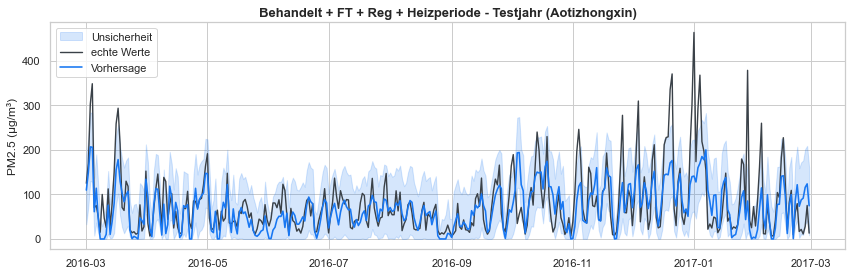

In [27]:
# Heizperiode 15.11.-15.03. als 0/1-Regressor, rein aus dem Datum (im Voraus bekannt -> kein Leakage)
def add_heizperiode(df):
    d = df.copy()
    mo, tag = d['ds'].dt.month, d['ds'].dt.day
    d['heizperiode'] = (((mo == 11) & (tag >= 15)) | mo.isin([12, 1, 2]) |
                        ((mo == 3) & (tag <= 15))).astype(int)
    return d

tr_h, te_h = lade('behandelt')
tr_h, te_h = add_heizperiode(tr_h), add_heizperiode(te_h)
regs_heiz = REGRESSOREN + ['heizperiode']

_, _, out_heiz = fit_predict(tr_h, te_h, regressoren=regs_heiz, log=False, feiertage='CN')

vgl_heiz = pd.DataFrame([
    {'Modell': 'Behandelt + FT + Reg',              **jahres_fehler(ergebnisse['Behandelt + Feiertage + Regressoren'], SKALA)},
    {'Modell': 'Behandelt + FT + Reg + Heizperiode', **jahres_fehler(out_heiz, SKALA)},
])
print(f'Wirkung der Heizperiode ({STATION}):'); print(vgl_heiz.to_string(index=False))
heiz_hor = fehler_horizonte(out_heiz, SKALA)
print('\nKurzfrist (mit Heizperiode):'); print(heiz_hor.to_string(index=False))

vgl_heiz.to_csv('../data/ergebnis_12_heizperiode.csv', index=False)
heiz_hor.to_csv('../data/ergebnis_12_heiz_horizonte.csv', index=False)
print('\ngespeichert -> ../data/ergebnis_12_heizperiode.csv')

plot_forecast(out_heiz, f'Behandelt + FT + Reg + Heizperiode - Testjahr ({STATION})')

### Auswertung Abschnitt 12 — Heizperiode wirkungslos

- **ohne** Heizperiode: RMSE 62,41 / MASE 0,6801  ·  **mit** Heizperiode: RMSE 62,29 / MASE 0,6817 — und über alle Horizonte identisch (8-h-MASE 0,18, 72-h 0,91). **Kein messbarer Effekt.**
- **Grund:** Prophets Jahressaisonalität bildet die Heizsaison-Form bereits ab; die scharfe An/Aus-Stufe ist redundant.
- **Trotzdem wichtig:** Die Heizperiode wäre der *einzige operativ ehrliche* Regressor (im Voraus bekannt, kein Leakage). Dass ausgerechnet sie nichts bringt, zeigt: Prophets Gewinn kommt fast ganz aus dem (unrealistisch bekannten) Zukunftswetter.
- *Einschränkung:* nur an Aotizhongxin und als additiver Offset getestet. Gründlicher: Heizperiode ohne `yearly_seasonality` testen, oder den Regressor-Koeffizienten ansehen.

## 13. Ergebnis & Ausblick

**Ergebnis:** Baselines setzen die Messlatte; die Konfigurationsleiter zeigt den Beitrag jedes Bausteins über alle 12 Stationen, bewertet mit MAE/RMSE/MASE/MAPE fürs Testjahr und 8/24/48/72 h. Tuning (Abschnitt 9 & 11) und Heizperiode (Abschnitt 12) verbessern das Modell **nicht** — der Hebel liegt bei den Regressoren und der Datenqualität.

**Ehrliche Einordnung:**
- **Feiertage allein bringen nichts;** den Gewinn machen Wetter-Regressoren und die behandelten Daten.
- **Die Regressoren enthalten das echte Zukunftswetter** — kurzfristig sieht Prophet dadurch besser aus, als es operativ wäre.
- **Kurzfristig ist Prophet kaum besser als naiv** (rollierend 8-h-MASE ca. 1,0), erst übers Jahr klar (MASE ca. 0,73-0,84).
- **Log vs. Nicht-Log ist ein Horizont-Kompromiss:** Nicht-Log kurzfristig besser, Log übers Jahr und beim MAPE.
- **Tuning & Heizperiode wirkungslos** (Abschnitte 11-12).

**Nächster Schritt:** dieselbe Test-Logik für **Chronos** und **PatchTST** — mit denselben Zukunfts-Regressoren und gegen die ungekappten Test-Werte, damit alle drei Modelle fair vergleichbar sind.